# Trực quan hóa kết quả Phase 2

Notebook mô tả kết quả hiện có của tập phát triển gồm 809 truy vấn. Không huấn luyện mô hình, triển khai bộ chọn hay sửa CSV/JSON nguồn. Hình được lưu tại results/phase2/visualizations/.

## 0. Thiết lập

Nạp thư viện trực quan hóa và dữ liệu, xác định thư mục dự án, sau đó tạo thư mục lưu hình.

In [1]:
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Works when launched from the repository root or from notebooks/.
_candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((p for p in _candidates if (p / "results" / "phase2").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate results/phase2 from the notebook working directory")
PHASE2 = PROJECT_ROOT / "results" / "phase2"
FIG_DIR = PHASE2 / "visualizations"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TAUS = ("095", "098", "099")
MSTAR_PATHS = {t: PHASE2 / "02_oracle" / f"mstar_labels_tau{t}.csv" for t in TAUS}
ANALYSIS_PATHS = {t: PHASE2 / "03_analysis" / f"feature_mstar_analysis_tau{t}.csv" for t in TAUS}
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 220, "font.size": 10, "axes.titlesize": 13, "axes.labelsize": 10})
sns.set_theme(style="whitegrid", context="notebook")
print(f"Thư mục dự án: {PROJECT_ROOT}")
print(f"Thư mục lưu hình: {FIG_DIR}")


Thư mục dự án: D:\NAM 4\pooladapt
Thư mục lưu hình: D:\NAM 4\pooladapt\results\phase2\visualizations


## 1. Nạp dữ liệu và kiểm tra nhất quán

Nạp trực tiếp các file Phase 2 hiện có. Bảng kiểm tra tóm tắt số truy vấn, query trùng, mức M*, tau, số feature, giá trị thiếu và độ khớp population. Nếu có khác biệt, notebook ghi cảnh báo và không tự sửa dữ liệu.

In [2]:
mstar = {t: pd.read_csv(path) for t, path in MSTAR_PATHS.items()}
mstar_summary = json.loads((PHASE2 / "02_oracle" / "mstar_analysis_tau095.json").read_text(encoding="utf-8"))
feature_mstar = {t: pd.read_csv(path) for t, path in ANALYSIS_PATHS.items()}
easy_hard = pd.read_csv(PHASE2 / "05_easy_hard_analysis" / "feature_easy_hard_analysis.csv")
gap_df = pd.read_csv(PHASE2 / "04_prefix10_gap_audit.csv")
pool_features = pd.read_csv(PHASE2 / "01_candidate_logging" / "pool_features.csv")
query_features = pd.read_csv(PHASE2 / "01_candidate_logging" / "query_features.csv")
multicollinearity = pd.read_csv(PHASE2 / "03_analysis" / "multicollinearity.csv")

warnings_found = []
def warn_if(condition, message):
    if condition:
        warnings_found.append(message)
        print("CẢNH BÁO:", message)

rows = []
for tau, df in mstar.items():
    rows.append({
        "artifact": f"M* tau={(int(tau) / 100):.2f}",
        "rows": len(df),
        "unique query_id": df["query_id"].nunique(),
        "duplicate query_id": int(df["query_id"].duplicated().sum()),
        "unique M_star": df["M_star"].nunique(),
        "tau values": ", ".join(map(str, sorted(df["tau"].dropna().unique()))),
        "missing cells": int(df.isna().sum().sum()),
    })
    warn_if(df["query_id"].duplicated().any(), f"query_id bị lặp trong nhãn M*, tau={tau}")
    warn_if(df.isna().any().any(), f"có giá trị thiếu trong nhãn M*, tau={tau}")
    expected_tau = int(tau) / 100
    observed_tau = set(df["tau"].dropna().astype(float).unique())
    warn_if(observed_tau != {expected_tau}, f"tau không đúng trong nhãn M*, tau={tau}: {sorted(observed_tau)}")

mstar_ids = {t: set(df["query_id"].astype(str)) for t, df in mstar.items()}
mstar_identical = all(
    mstar["095"].set_index("query_id")["M_star"].sort_index().equals(
        mstar[t].set_index("query_id")["M_star"].sort_index()
    ) for t in ("098", "099")
)
print("M* giống nhau giữa các tau:", mstar_identical)
for tau, df in feature_mstar.items():
    rows.append({"artifact": f"Feature-M* tau={(int(tau) / 100):.2f}", "rows": len(df), "unique query_id": "không áp dụng (bảng theo feature)", "duplicate query_id": "n/a", "unique M_star": "n/a", "tau values": ", ".join(map(str, sorted(df["tau"].dropna().unique()))), "missing cells": int(df.isna().sum().sum())})
    warn_if(df["feature_name"].duplicated().any(), f"tên feature bị lặp trong phân tích feature-M*, tau={tau}")
    warn_if(df.isna().any().any(), f"có giá trị thiếu trong phân tích feature-M*, tau={tau}")
    expected_tau = int(tau) / 100
    observed_tau = set(df["tau"].dropna().astype(float).unique())
    warn_if(observed_tau != {expected_tau}, f"tau không đúng trong phân tích feature-M*, tau={tau}: {sorted(observed_tau)}")

for name, df in [("pool_features", pool_features), ("query_features", query_features), ("prefix10_gap", gap_df)]:
    qids = df["query_id"].astype(str)
    rows.append({"artifact": name, "rows": len(df), "unique query_id": qids.nunique(), "duplicate query_id": int(qids.duplicated().sum()), "unique M_star": "n/a", "tau values": "n/a", "missing cells": int(df.isna().sum().sum())})
    warn_if(qids.duplicated().any(), f"query_id bị lặp trong {name}")
    missing_columns = [col for col in df.columns if df[col].isna().any() and not (name == "query_features" and col == "entity_count")]
    warn_if(bool(missing_columns), f"giá trị thiếu ngoài dự kiến trong {name}: {missing_columns}")

rows.append({"artifact": "Easy/hard aggregate", "rows": len(easy_hard), "unique query_id": "không áp dụng (bảng tổng hợp)", "duplicate query_id": "n/a", "unique M_star": "n/a", "tau values": "n/a", "missing cells": int(easy_hard.isna().sum().sum())})
easy_hard_counts = easy_hard.loc[easy_hard["feature"] != "entity_count", ["n_easy", "n_hard"]].drop_duplicates().rename(columns={"n_easy":"Số truy vấn Easy", "n_hard":"Số truy vấn Hard"})
print("Số truy vấn theo nhóm Easy/Hard:")
display(easy_hard_counts)
print("Số feature theo từng tau:", {t: len(df) for t, df in feature_mstar.items()})
print("entity_count thiếu ở toàn bộ truy vấn nên được loại khỏi biểu đồ.")

reference_ids = mstar_ids["095"]
population_matches = {}
for name, df in [("pool_features", pool_features), ("query_features", query_features), ("prefix10_gap", gap_df)]:
    ids = set(df["query_id"].astype(str))
    population_matches[name] = ids == reference_ids
    warn_if(ids != reference_ids, f"population truy vấn không khớp giữa M* tau=095 và {name} (M*={len(reference_ids)}, {name}={len(ids)})")
for row in rows:
    if row["artifact"] in population_matches:
        row["population matches M* tau=095"] = population_matches[row["artifact"]]

sanity_summary = pd.DataFrame(rows)
sanity_display = sanity_summary.copy()
sanity_display["artifact"] = sanity_display["artifact"].replace({"pool_features":"Đặc trưng Candidate Pool","query_features":"Đặc trưng Query","prefix10_gap":"Kiểm tra gap Prefix-10","Easy/hard aggregate":"Tổng hợp Easy/Hard"})
sanity_display = sanity_display.rename(columns={"artifact":"Tệp/nhóm","rows":"Số dòng","unique query_id":"Số query duy nhất","duplicate query_id":"Số query trùng","unique M_star":"Số mức M*","tau values":"Giá trị tau","missing cells":"Số ô thiếu","population matches M* tau=095":"Population khớp M* tau=0,95"})
display(sanity_display)
if not mstar_identical:
    warn_if(True, "M* assignments differ across tau; Chart 1/2 use tau=0.95 as the requested representative, and feature association chart will show tau panels.")
print(f"Số cảnh báo kiểm tra: {len(warnings_found)}")


M* giống nhau giữa các tau: True
Số truy vấn theo nhóm Easy/Hard:
 Số truy vấn Easy  Số truy vấn Hard
              757                52
Số feature theo từng tau: {'095': 19, '098': 19, '099': 19}
entity_count thiếu ở toàn bộ truy vấn nên được loại khỏi biểu đồ.
                Tệp/nhóm  Số dòng                 Số query duy nhất Số query trùng Số mức M* Giá trị tau  Số ô thiếu Population khớp M* tau=0,95
             M* tau=0.95      809                               809              0         5        0.95           0                         NaN
             M* tau=0.98      809                               809              0         5        0.98           0                         NaN
             M* tau=0.99      809                               809              0         5        0.99           0                         NaN
     Feature-M* tau=0.95       19 không áp dụng (bảng theo feature)            n/a       n/a        0.95           0                         NaN
     Featur

M* tại tau=0,95, 0,98 và 0,99 giống nhau trong các file nhãn hiện có; do đó tau=0,95 được dùng làm hình đại diện.

## 2. Phân bố oracle M*

Nguồn: 02_oracle/mstar_labels_tau095.csv. Đơn vị phân tích: truy vấn. Biểu đồ cột thể hiện số truy vấn tại từng ngân sách M*; CDF thể hiện tỷ lệ truy vấn tích lũy đến từng mức.

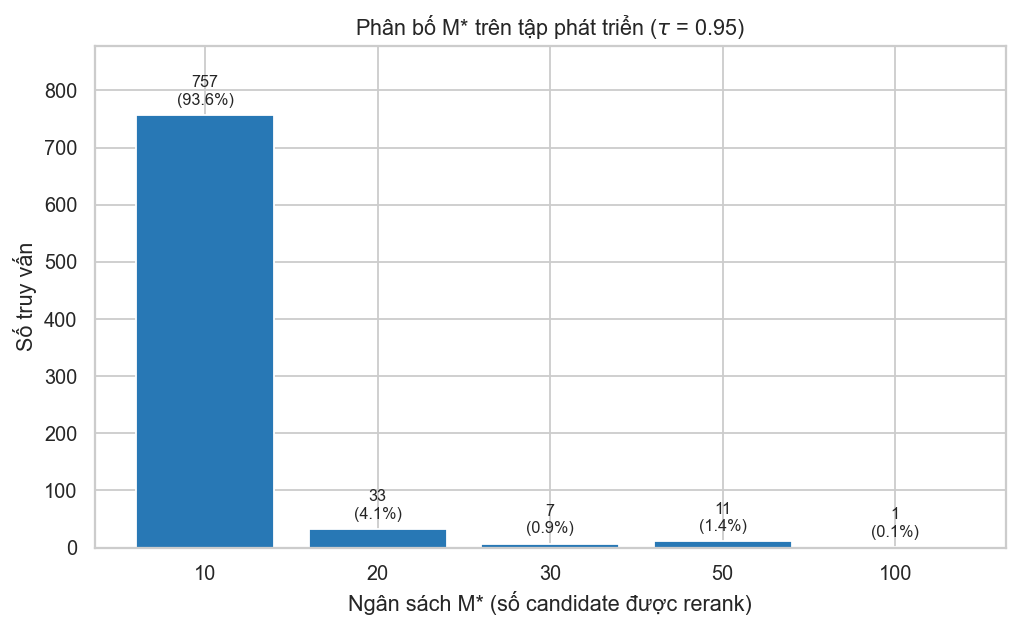

In [3]:
mstar_plot = mstar["095"].copy()
mstar_counts = mstar_plot["M_star"].value_counts().sort_index()
percentages = 100 * mstar_counts / mstar_counts.sum()
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(mstar_counts.index.astype(str), mstar_counts.values, color="#2878B5", edgecolor="white")
for bar, count, pct in zip(bars, mstar_counts.values, percentages.values):
    ax.annotate(f"{count}\n({pct:.1f}%)", (bar.get_x()+bar.get_width()/2, bar.get_height()), xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=9)
ax.set(title="Phân bố M* trên tập phát triển ($\\tau$ = 0.95)", xlabel="Ngân sách M* (số candidate được rerank)", ylabel="Số truy vấn")
ax.set_ylim(0, max(mstar_counts.values) * 1.16)
fig.tight_layout(); fig.savefig(FIG_DIR / "01_mstar_distribution.png", bbox_inches="tight"); plt.show()



### Nhận xét

- Biểu đồ gồm **809 truy vấn** và có năm mức M*: 10, 20, 30, 50 và 100.
- Mức M*=10 chiếm ưu thế với **757/809 truy vấn (93,57%)**; các mức còn lại có 33, 7, 11 và 1 truy vấn.
- Nhiều mức M* cùng xuất hiện, cho thấy ngân sách oracle quan sát được có biến thiên giữa các truy vấn.
- Đây là mô tả phân bố nhãn M*, không phải bằng chứng rằng PoolAdapt đã được kiểm chứng.

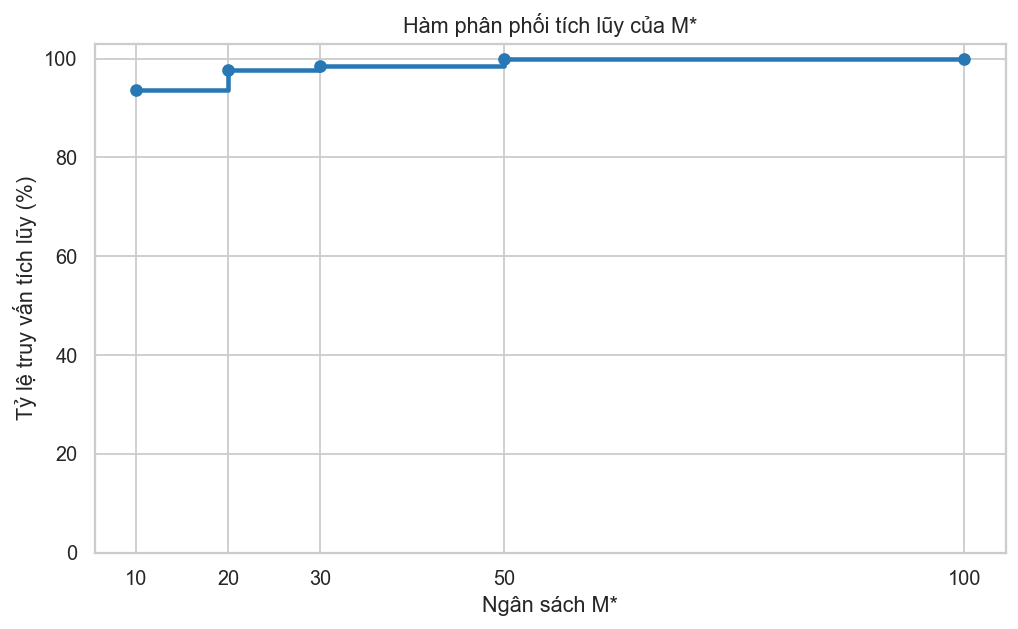

In [4]:
cdf = mstar_counts.cumsum() / mstar_counts.sum() * 100
fig, ax = plt.subplots(figsize=(8, 5))
ax.step(cdf.index, cdf.values, where="post", color="#2878B5", linewidth=2.5)
ax.scatter(cdf.index, cdf.values, color="#2878B5", zorder=3)
ax.set(title="Hàm phân phối tích lũy của M*", xlabel="Ngân sách M*", ylabel="Tỷ lệ truy vấn tích lũy (%)", ylim=(0, 103), xticks=cdf.index)
fig.tight_layout(); fig.savefig(FIG_DIR / "02_mstar_cdf.png", bbox_inches="tight"); plt.show()


### Nhận xét

- CDF tăng nhanh: **93,57%** truy vấn đạt M* không quá 10; tỷ lệ tích lũy đạt **97,65%** tại 20 và **98,52%** tại 30.
- Đến M*=50, tỷ lệ tích lũy là **99,88%**; truy vấn còn lại đạt mức 100.
- Phân bố tập trung mạnh ở ngân sách nhỏ, đồng thời có một nhóm nhỏ ở ngân sách lớn hơn.

## 3. Tương quan Spearman giữa feature và M*

Nguồn: ba file feature_mstar_analysis_tau*.csv. Đơn vị phân tích: feature; feature cấp candidate đã được tổng hợp qua N=100 candidate cho mỗi truy vấn. Hình thể hiện rho, p_Holm và điều kiện G2; cột selected được giữ nguyên như trong file nguồn.

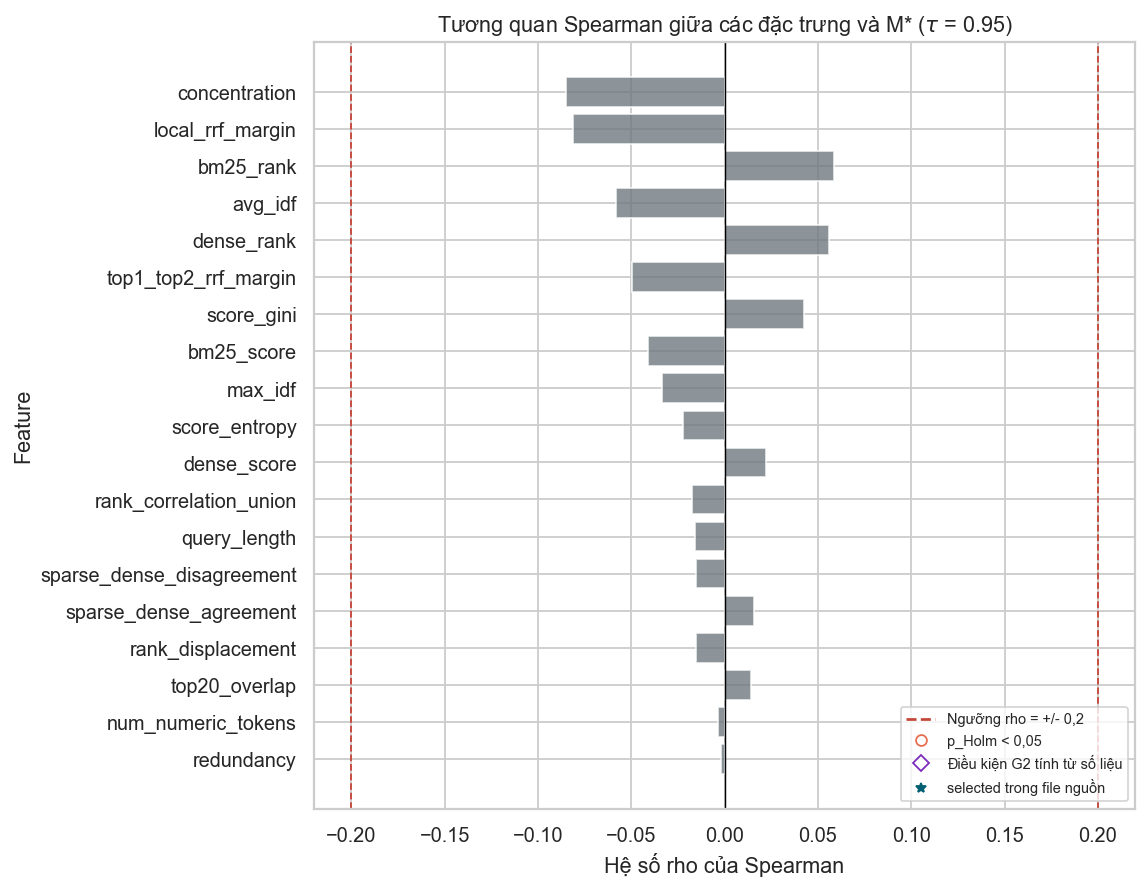

Thống kê feature-M* giống nhau giữa các tau (bỏ cột tau): True


In [5]:
analysis_identical = all(
    feature_mstar["095"].drop(columns=["tau"]).reset_index(drop=True).equals(
        feature_mstar[t].drop(columns=["tau"]).reset_index(drop=True)
    ) for t in ("098", "099")
)
print("Thống kê feature-M* giống nhau giữa các tau (bỏ cột tau):", analysis_identical)

def plot_feature_assoc(df, title, ax):
    d = df.sort_values("abs_rho", ascending=True).copy()
    g2_screen = (d["abs_rho"] > 0.2) & (d["p_holm"] < 0.05)
    holm_sig = d["p_holm"] < 0.05
    colors = np.where(d["selected"].astype(bool), "#2A9D8F", "#6C757D")
    ax.barh(d["feature_name"], d["spearman_rho"], color=colors, alpha=0.78)
    ax.axvline(-0.2, color="#C44536", linestyle="--", linewidth=1, label="Ngưỡng rho: -0,2 và +0,2")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.axvline(0.2, color="#C44536", linestyle="--", linewidth=1)
    for y, (_, row) in enumerate(d.iterrows()):
        if holm_sig.iloc[y]:
            ax.plot(row["spearman_rho"], y, marker="o", markerfacecolor="none", markeredgecolor="#E76F51", markersize=8, linestyle="None")
        if g2_screen.iloc[y]:
            ax.plot(row["spearman_rho"], y, marker="D", markerfacecolor="none", markeredgecolor="#7B2CBF", markersize=8, linestyle="None")
        if bool(row["selected"]):
            ax.plot(row["spearman_rho"], y, marker="*", color="#005F73", markersize=10, linestyle="None")
    ax.set(title=title, xlabel="Hệ số rho của Spearman", ylabel="Feature")

if analysis_identical:
    fig, ax = plt.subplots(figsize=(9, 7))
    plot_feature_assoc(feature_mstar["095"], "Tương quan Spearman giữa các đặc trưng và M* ($\\tau$ = 0.95)", ax)
    from matplotlib.lines import Line2D
    ax.legend(handles=[Line2D([0],[0], color="#C44536", ls="--", label="Ngưỡng rho = +/- 0,2"), Line2D([0],[0], marker="o", markerfacecolor="none", markeredgecolor="#E76F51", ls="None", label="p_Holm < 0,05"), Line2D([0],[0], marker="D", markerfacecolor="none", markeredgecolor="#7B2CBF", ls="None", label="Điều kiện G2 tính từ số liệu"), Line2D([0],[0], marker="*", color="#005F73", ls="None", label="selected trong file nguồn")], loc="lower right", fontsize=8)
    fig.tight_layout(); fig.savefig(FIG_DIR / "03_feature_mstar_spearman.png", bbox_inches="tight"); plt.show()
else:
    fig, axes = plt.subplots(1, 3, figsize=(21, 7), sharex=True)
    for ax, tau in zip(axes, TAUS): plot_feature_assoc(feature_mstar[tau], f"tau = 0,{int(tau)/100:.2f}", ax)
    fig.suptitle("Tương quan Spearman giữa feature và M* theo tau", y=1.02)
    fig.tight_layout(); fig.savefig(FIG_DIR / "03_feature_mstar_spearman.png", bbox_inches="tight"); plt.show()


### Nhận xét

- Hệ số Spearman nằm trong khoảng xấp xỉ **-0,085 đến 0,059**.
- Trị tuyệt đối lớn nhất thuộc về **concentration** (rho=-0,0847), tiếp theo là **local_rrf_margin** (rho=-0,0812).
- Không feature nào thỏa G2 định trước: **|rho| > 0,2 và p_Holm < 0,05**. Cả 19 dòng đều có selected=False.
- Không feature nào vượt tiêu chí sàng lọc đơn biến đã đặt ra; điều đó không đồng nghĩa các feature vô dụng.

## 4. Phân tích nhóm Easy và Hard

Nguồn: 05_easy_hard_analysis/feature_easy_hard_analysis.csv. Đơn vị: feature, tổng hợp theo nhóm truy vấn Easy/Hard. Loại entity_count khỏi hình vì không có quan sát. AUC và chênh lệch trung bình là mô tả; p_Holm được xét riêng.

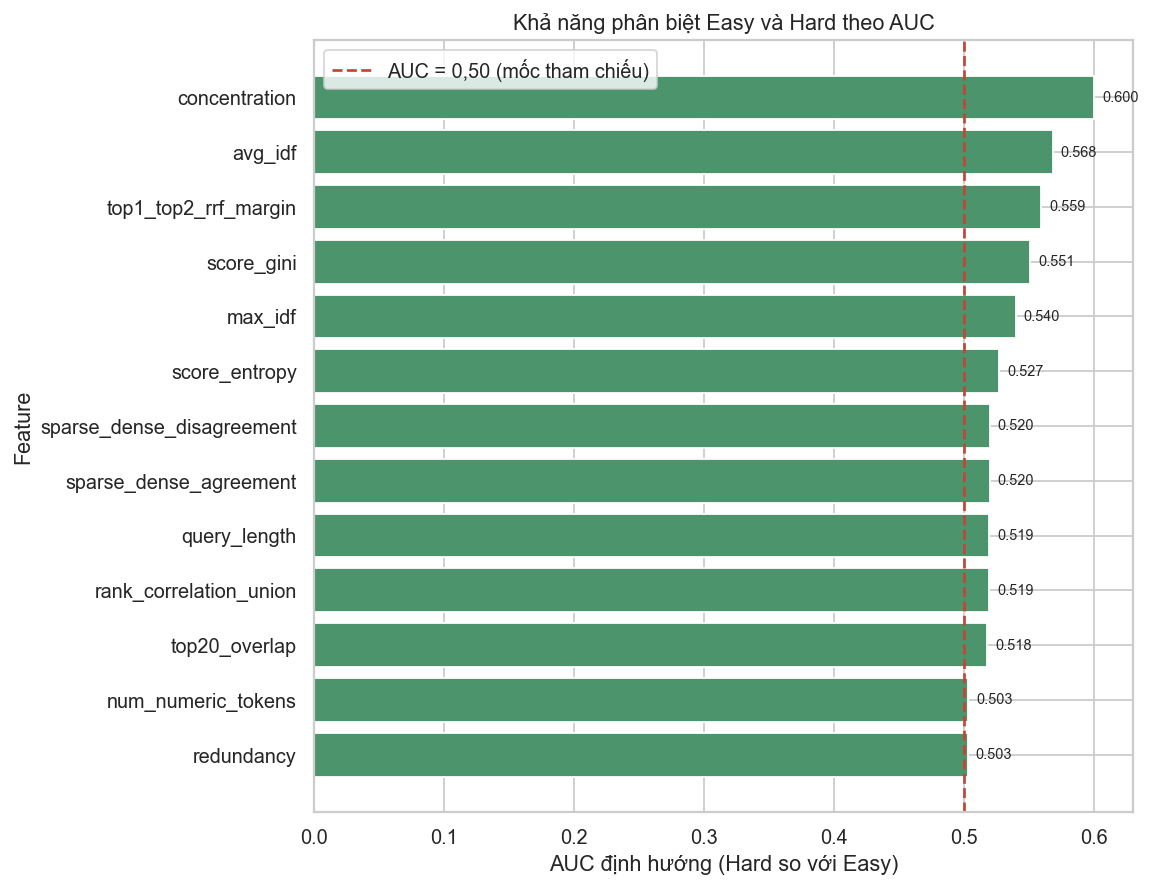

In [6]:
eh = easy_hard.loc[easy_hard["feature"] != "entity_count"].dropna(subset=["auc_directional", "mean_difference_hard_minus_easy"]).copy()
eh_auc = eh.sort_values("auc_directional", ascending=True)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(eh_auc["feature"], eh_auc["auc_directional"], color="#4C956C")
ax.axvline(0.5, color="#C44536", linestyle="--", label="AUC = 0,50 (mốc tham chiếu)")
for y, value in enumerate(eh_auc["auc_directional"]): ax.text(value + 0.006, y, f"{value:.3f}", va="center", fontsize=8)
ax.set(title="Khả năng phân biệt Easy và Hard theo AUC", xlabel="AUC định hướng (Hard so với Easy)", ylabel="Feature")
ax.legend(); fig.tight_layout(); fig.savefig(FIG_DIR / "04_easy_hard_auc.png", bbox_inches="tight"); plt.show()



### Nhận xét

- AUC=0,50 là mốc tham chiếu tương ứng với khả năng phân biệt không cao hơn ngẫu nhiên theo hướng định nghĩa của chỉ số.
- AUC định hướng lớn nhất là **concentration=0,600**, tiếp theo **avg_idf=0,568** và **top1_top2_rrf_margin=0,559**.
- concentration có p-value thô nhỏ nhất (**0,0159**), nhưng p_Holm là **0,2226**; không feature nào có p_Holm < 0,05.
- AUC hiện tại chưa cung cấp bằng chứng mạnh sau hiệu chỉnh Holm; không diễn giải chỉ số này như bằng chứng về khả năng dự đoán.

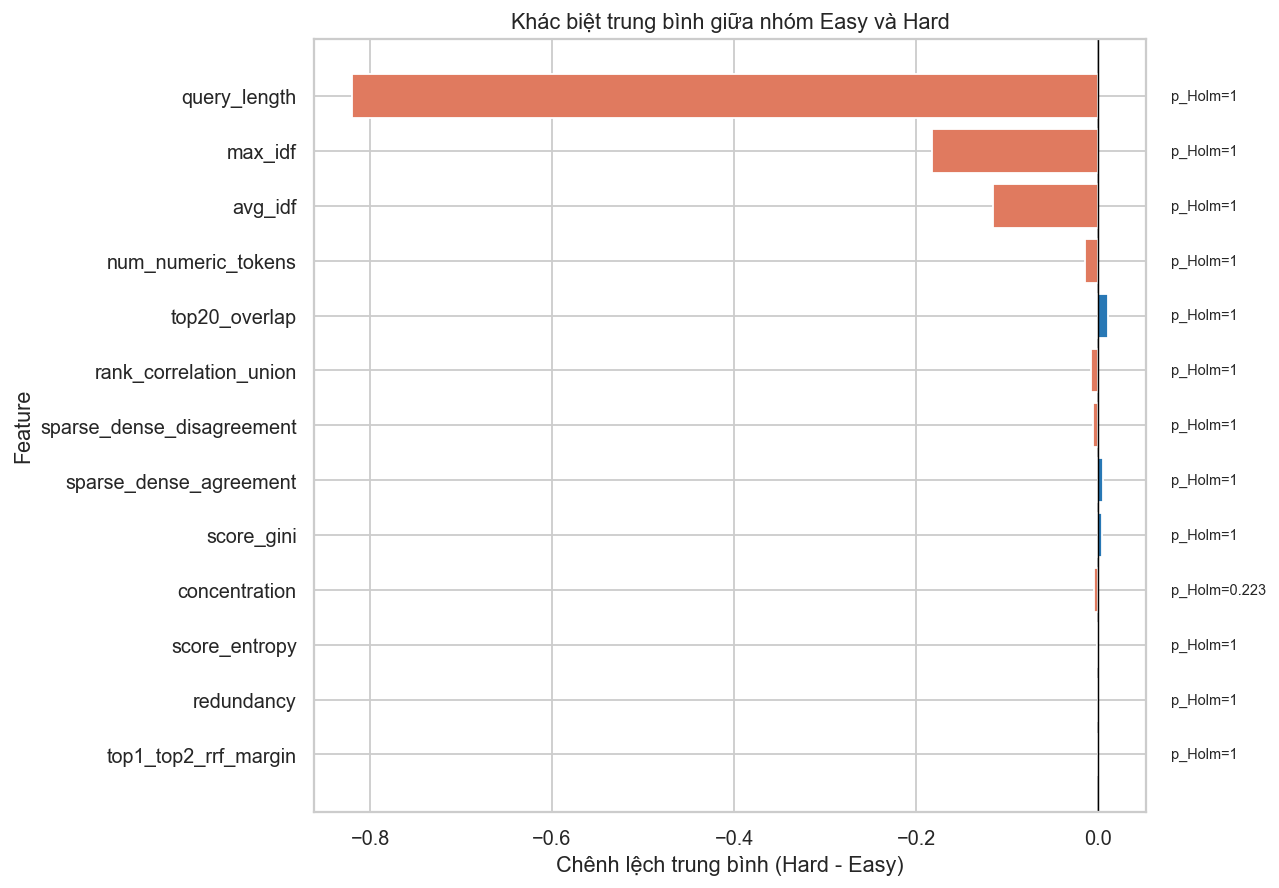

In [7]:
eh_diff = eh.assign(abs_difference=eh["mean_difference_hard_minus_easy"].abs()).sort_values("abs_difference", ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
colors = np.where(eh_diff["mean_difference_hard_minus_easy"] >= 0, "#2878B5", "#E07A5F")
ax.barh(eh_diff["feature"], eh_diff["mean_difference_hard_minus_easy"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
for y, (_, row) in enumerate(eh_diff.iterrows()):
    ax.text(1.03, y, f"p_Holm={row['p_holm']:.3g}", transform=ax.get_yaxis_transform(), ha="left", va="center", fontsize=8, clip_on=False)
ax.set(title="Khác biệt trung bình giữa nhóm Easy và Hard", xlabel="Chênh lệch trung bình (Hard - Easy)", ylabel="Feature")
fig.subplots_adjust(right=0.76); fig.tight_layout(); fig.savefig(FIG_DIR / "05_easy_hard_mean_difference.png", bbox_inches="tight"); plt.show()


### Nhận xét

- Chênh lệch Hard-Easy lớn nhất theo trị tuyệt đối là **query_length=-0,820**; tiếp theo **max_idf=-0,182** và **avg_idf=-0,115**, đều thấp hơn ở nhóm Hard.
- Chênh lệch dương lớn nhất là **top20_overlap=+0,011**, cao hơn ở nhóm Hard.
- Không feature nào có p_Holm < 0,05. Khoảng cách trung bình là mô tả, không tự thân xác lập khác biệt có ý nghĩa thống kê.

## 5. Phân tích gap của Prefix-10

Nguồn: 04_prefix10_gap_audit.csv; đơn vị: truy vấn. Định nghĩa: **gap = nDCG@10(Full Rerank) - nDCG@10(Prefix-10)**. Hình đầu mô tả phân bố gap; hình sau ghép M* tau=0,95 với gap theo query_id.

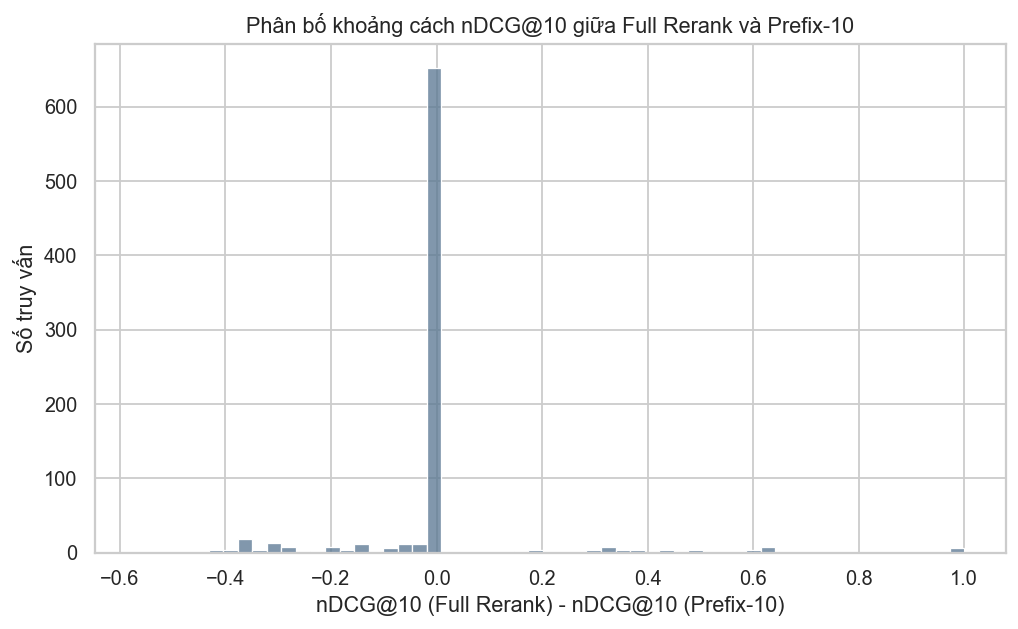

Trung bình gap: 0.001060
Trung vị gap: 0.000000
gap = 0: 650 truy vấn (80.35%)
gap > 0: 52 truy vấn (6.43%)
gap < 0: 107 truy vấn (13.23%)


In [8]:
g = gap_df["gap"].dropna()
zero_pct = (g == 0).mean() * 100
negative_pct = (g < 0).mean() * 100
positive_pct = (g > 0).mean() * 100
print(f"Trung bình gap: {g.mean():.6f}")
print(f"Trung vị gap: {g.median():.6f}")
print(f"gap = 0: {(g == 0).sum()} truy vấn ({zero_pct:.2f}%)")
print(f"gap > 0: {(g > 0).sum()} truy vấn ({positive_pct:.2f}%)")
print(f"gap < 0: {(g < 0).sum()} truy vấn ({negative_pct:.2f}%)")
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(g, bins="auto", ax=ax, color="#577590", edgecolor="white")
ax.set(title="Phân bố khoảng cách nDCG@10 giữa Full Rerank và Prefix-10", xlabel="nDCG@10 (Full Rerank) - nDCG@10 (Prefix-10)", ylabel="Số truy vấn")
fig.tight_layout(); fig.savefig(FIG_DIR / "06_prefix10_gap_distribution.png", bbox_inches="tight"); plt.show()



### Nhận xét

- Trong **809 truy vấn**, gap<0 ở **107 (13,23%)**, gap=0 ở **650 (80,35%)**, và gap>0 ở **52 (6,43%)**.
- Mean gap là **0,001060**; median là **0**.
- Gap âm nghĩa là Prefix-10 có nDCG@10 cao hơn Full Rerank ở truy vấn đó; đây là kết quả quan sát được, không mặc định là lỗi.
- Audit riêng không tìm thấy bất nhất triển khai trong artifacts hiện có. Tuy nhiên, artifacts phát triển không lưu đủ candidate ID, query/document text, reranker score hay runner train/validation gốc để tái dựng độc lập toàn pipeline cho từng truy vấn.

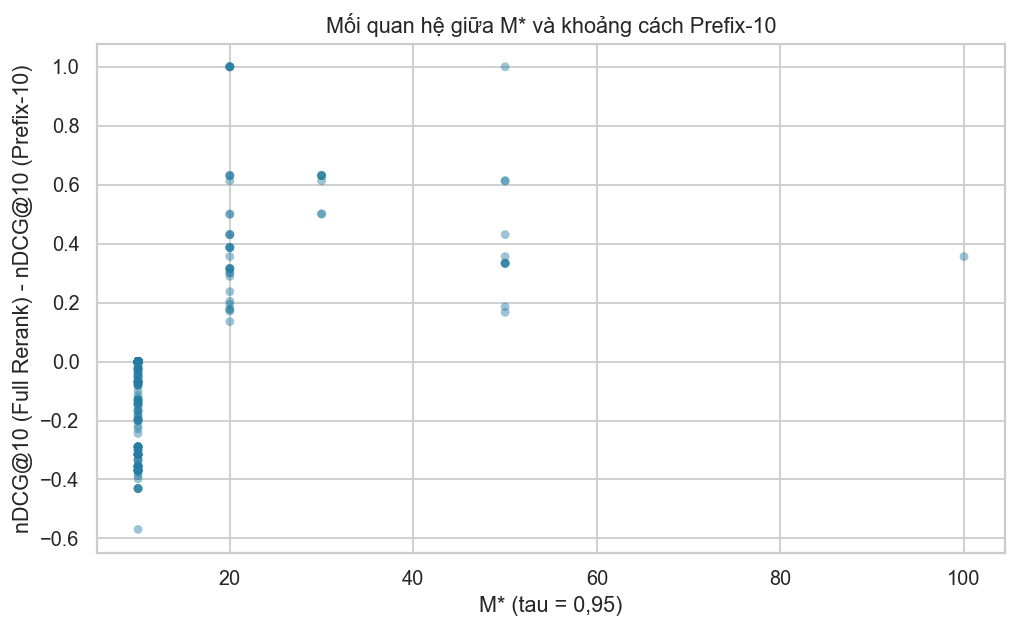

In [9]:
mstar_gap = mstar["095"][["query_id", "M_star"]].merge(gap_df[["query_id", "gap"]], on="query_id", how="inner", validate="one_to_one")
if len(mstar_gap) != len(mstar["095"]) or len(mstar_gap) != len(gap_df):
    warn_if(True, f"Ghép M* với gap còn {len(mstar_gap)} dòng (M*={len(mstar['095'])}, gap={len(gap_df)})")
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(mstar_gap["M_star"], mstar_gap["gap"], alpha=0.45, s=24, color="#277DA1", edgecolors="none")
ax.set(title="Mối quan hệ giữa M* và khoảng cách Prefix-10", xlabel="M* (tau = 0,95)", ylabel="nDCG@10 (Full Rerank) - nDCG@10 (Prefix-10)")
fig.tight_layout(); fig.savefig(FIG_DIR / "07_mstar_vs_prefix10_gap.png", bbox_inches="tight"); plt.show()


### Nhận xét

- Các điểm tập trung dày tại M*=10, phù hợp với phân bố M* gồm 757/809 truy vấn ở mức này; tại đó gap trải từ âm đến bằng 0.
- Các mức M* từ 20 trở lên tạo thành cụm thưa hơn; trong dữ liệu đang vẽ, các truy vấn ở các mức này có gap dương.
- Đây là mô tả đồng biến thiên giữa hai đại lượng theo truy vấn. Scatter plot không xác lập rằng M* gây ra thay đổi của gap, cũng không thay thế kiểm tra đầy đủ đầu vào reranking.

## 6. Các cặp feature có tương quan cao

Nguồn: 03_analysis/multicollinearity.csv. Đơn vị: cặp feature đã được đánh dấu. Đây là hình chẩn đoán các cặp trong file, không phải ma trận tương quan đầy đủ.

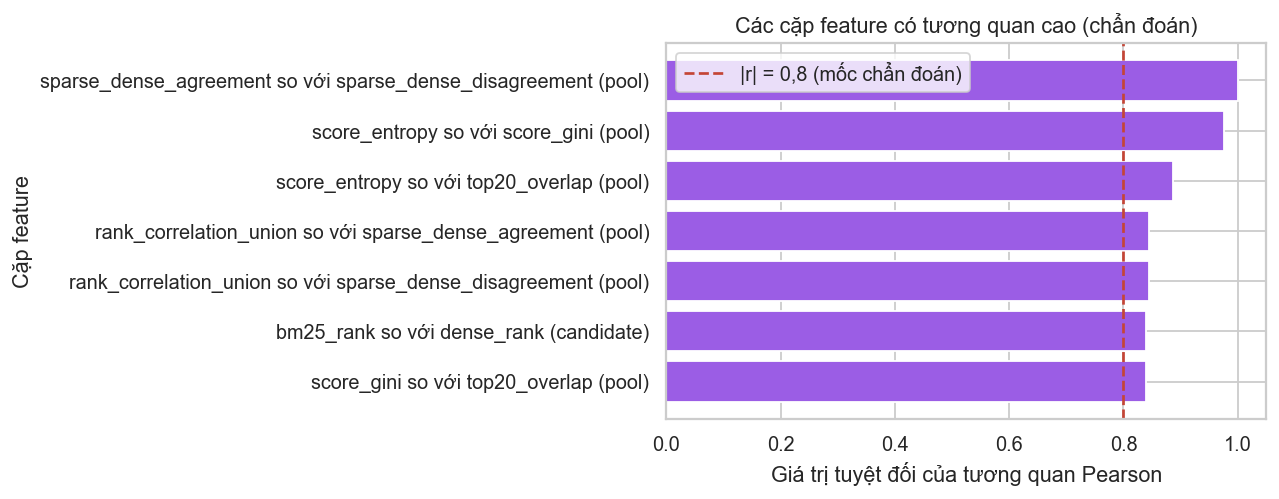

In [10]:
mc = multicollinearity.copy()
mc["feature_pair"] = mc["feature_a"].astype(str) + " so với " + mc["feature_b"].astype(str) + " (" + mc["feature_level"].astype(str) + ")"
mc["abs_r"] = mc["pearson_r"].abs()
mc = mc.sort_values("abs_r", ascending=True)
fig, ax = plt.subplots(figsize=(10, max(4, 0.55 * len(mc))))
ax.barh(mc["feature_pair"], mc["abs_r"], color="#9B5DE5")
ax.axvline(0.8, color="#C44536", linestyle="--", label="|r| = 0,8 (mốc chẩn đoán)")
ax.set(title="Các cặp feature có tương quan cao (chẩn đoán)", xlabel="Giá trị tuyệt đối của tương quan Pearson", ylabel="Cặp feature", xlim=(0, 1.05))
ax.legend(); fig.tight_layout(); fig.savefig(FIG_DIR / "08_multicollinearity.png", bbox_inches="tight"); plt.show()


### Nhận xét

- Mối liên hệ mạnh nhất là sparse_dense_agreement với sparse_dense_disagreement (**r=-1,000**); score_entropy với score_gini cũng rất cao về trị tuyệt đối (**r=-0,977**).
- Các cặp bm25_rank-dense_rank (**r=0,839**) và rank_correlation_union-sparse_dense_agreement (**r=0,844**) cũng tương quan cao.
- Tương quan cao cho thấy feature có thể chia sẻ thông tin hoặc dư thừa. Cần cân nhắc điều này khi xây dựng mô hình đa biến; hình không tự quyết định feature nào cần giữ hay loại.

## 7. Phân bố feature của Candidate Pool và Query

Nguồn: 01_candidate_logging/pool_features.csv và query_features.csv. Đơn vị: truy vấn (mỗi dòng chứa đặc trưng của một Candidate Pool hoặc Query). Histogram mô tả phạm vi và hình dạng phân bố; entity_count hoàn toàn thiếu nên không được vẽ.

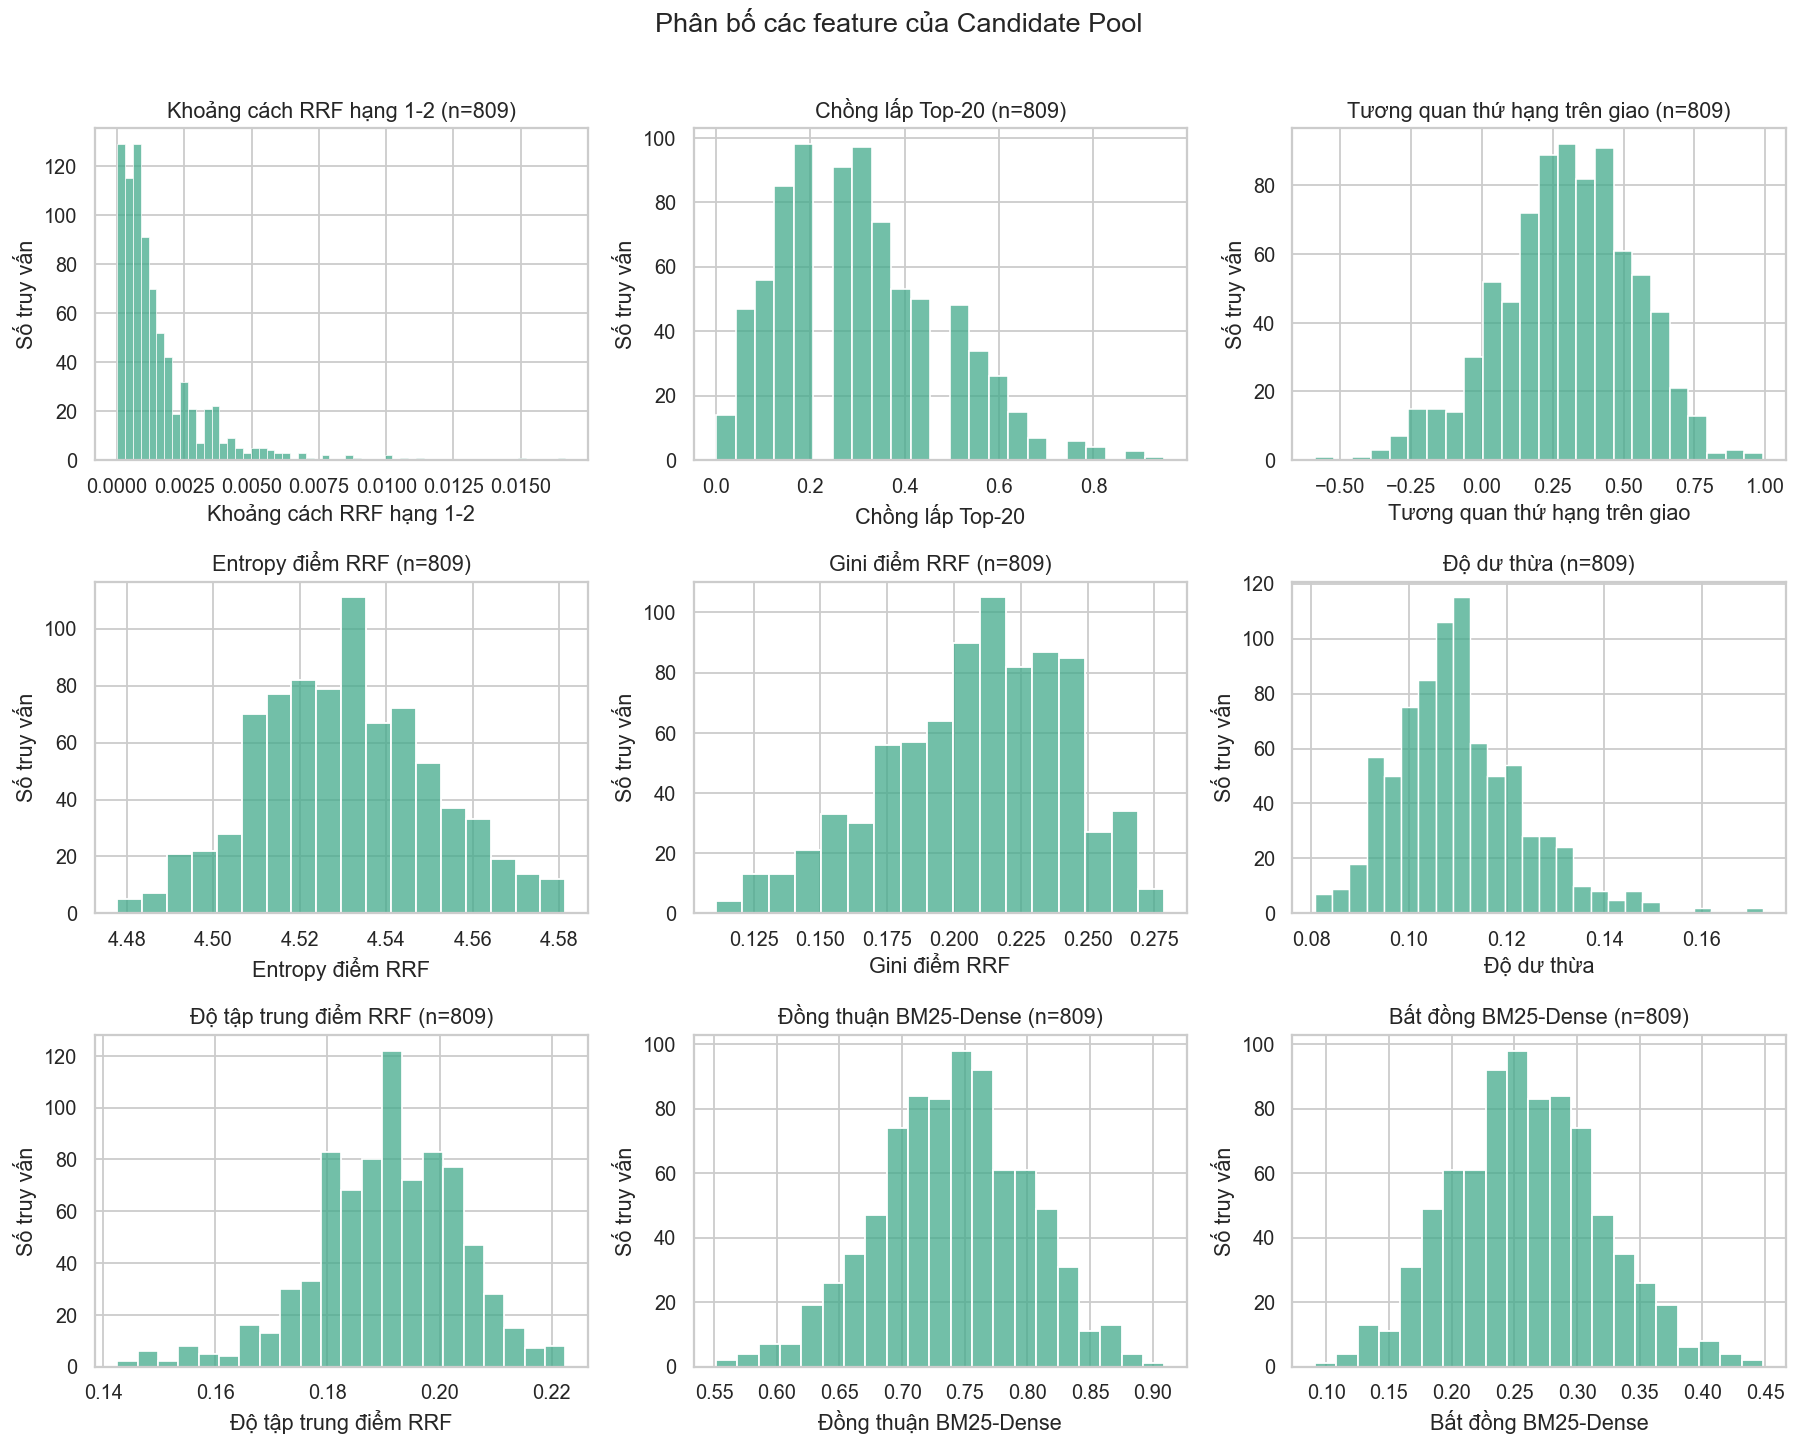

In [11]:
pool_columns = ["top1_top2_rrf_margin", "top20_overlap", "rank_correlation_union", "score_entropy", "score_gini", "redundancy", "concentration", "sparse_dense_agreement", "sparse_dense_disagreement"]
pool_labels = {"top1_top2_rrf_margin":"Khoảng cách RRF hạng 1-2","top20_overlap":"Chồng lấp Top-20","rank_correlation_union":"Tương quan thứ hạng trên giao","score_entropy":"Entropy điểm RRF","score_gini":"Gini điểm RRF","redundancy":"Độ dư thừa","concentration":"Độ tập trung điểm RRF","sparse_dense_agreement":"Đồng thuận BM25-Dense","sparse_dense_disagreement":"Bất đồng BM25-Dense"}
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for ax, col in zip(axes.flat, pool_columns):
    values = pool_features[col].dropna()
    sns.histplot(values, bins="auto", ax=ax, color="#43AA8B", edgecolor="white")
    ax.set(title=f"{pool_labels[col]} (n={len(values)})", xlabel=pool_labels[col], ylabel="Số truy vấn")
fig.suptitle("Phân bố các feature của Candidate Pool", y=1.01, fontsize=15)
fig.tight_layout(); fig.savefig(FIG_DIR / "09_pool_feature_distributions.png", bbox_inches="tight"); plt.show()



### Nhận xét

- Khoảng cách RRF hạng 1-2 tập trung gần 0 và lệch phải: trung vị **0,00103**, lớn nhất **0,01666**. Chồng lấp Top-20 có trung vị **0,30**, phạm vi 0-0,95.
- Tương quan thứ hạng trên giao có phạm vi rộng (**-0,588 đến 0,992**); entropy điểm RRF tập trung hơn trong khoảng **4,478-4,581**.
- score_gini nằm trong khoảng **0,111-0,279**, redundancy **0,081-0,173**, concentration **0,142-0,222**. Các histogram chỉ mô tả phân bố, không đánh giá khả năng dự đoán M*.

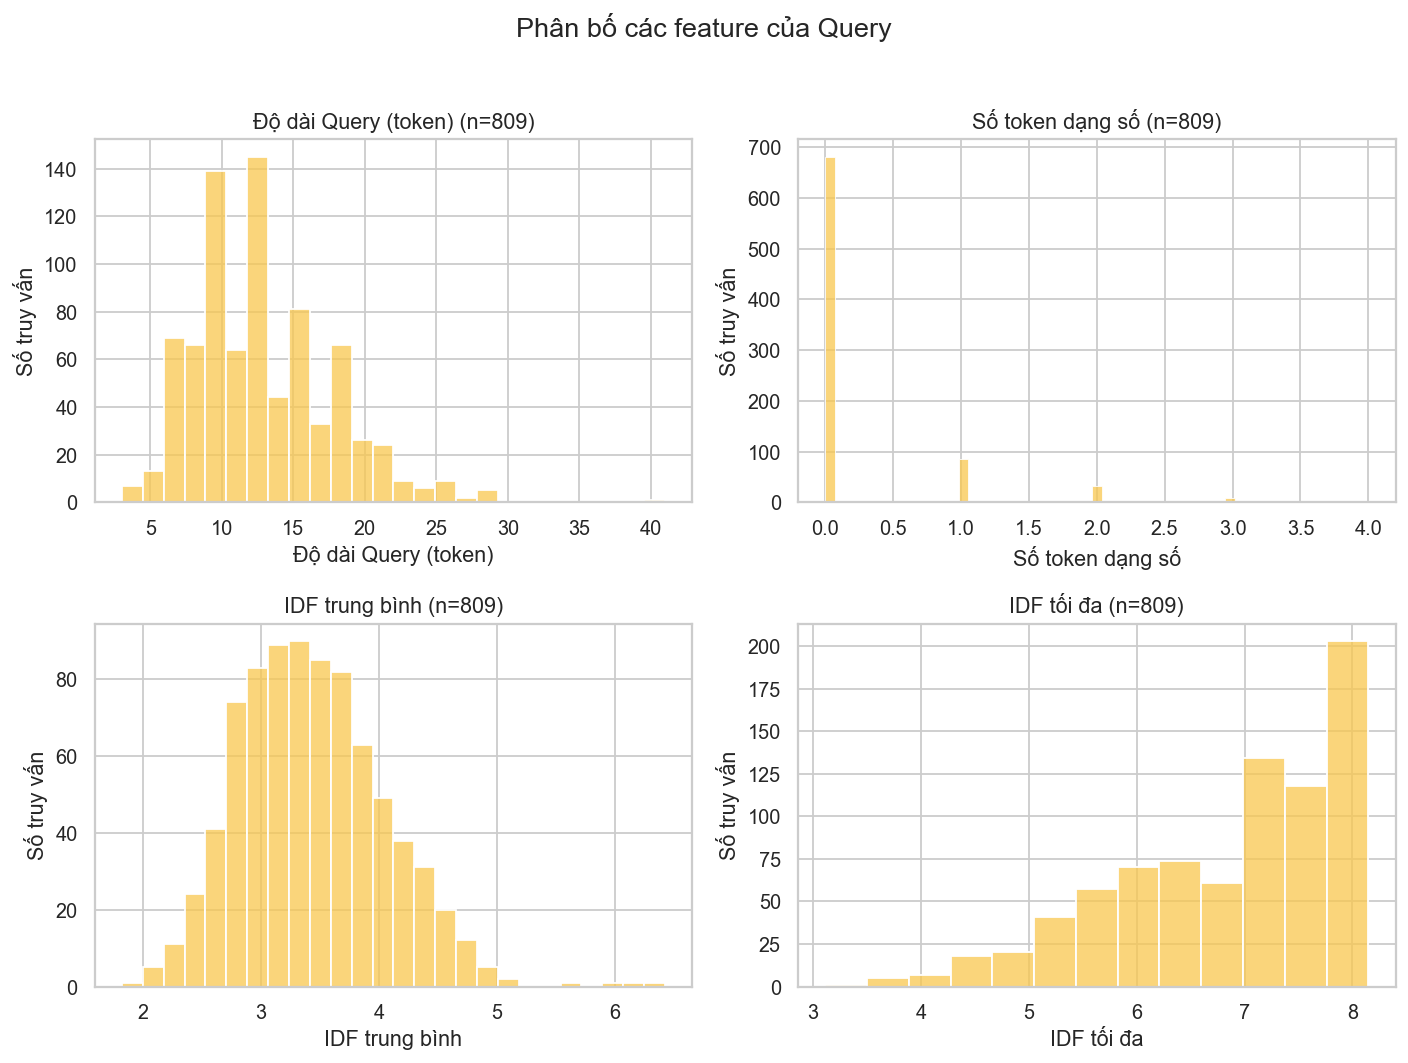

In [12]:
query_columns = ["query_length", "num_numeric_tokens", "avg_idf", "max_idf"]
query_labels = {"query_length":"Độ dài Query (token)","num_numeric_tokens":"Số token dạng số","avg_idf":"IDF trung bình","max_idf":"IDF tối đa"}
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flat, query_columns):
    values = query_features[col].dropna()
    sns.histplot(values, bins="auto", ax=ax, color="#F9C74F", edgecolor="white")
    ax.set(title=f"{query_labels[col]} (n={len(values)})", xlabel=query_labels[col], ylabel="Số truy vấn")
fig.suptitle("Phân bố các feature của Query", y=1.02, fontsize=15)
fig.tight_layout(); fig.savefig(FIG_DIR / "10_query_feature_distributions.png", bbox_inches="tight"); plt.show()


### Nhận xét

- Độ dài Query nằm trong khoảng **3-41 token**, trung vị **12 token**. Số token dạng số có trung vị 0 và bách phân vị 75 cũng bằng 0.
- IDF trung bình trải từ **1,82 đến 6,42**; IDF tối đa từ **3,11 đến 8,15**.
- entity_count thiếu ở toàn bộ **809 truy vấn** nên được loại khỏi biểu đồ; không thể rút ra nhận xét về thực thể từ trường này.
- Các phân bố này không cho biết quan hệ giữa đặc trưng Query và M* nếu chỉ nhìn riêng biểu đồ.

## 8. Kiểm tra hình đã tạo

Bảng sau xác nhận các file hình đã lưu. Mỗi hình cũng được nhúng trong output của cell tương ứng.

In [13]:
expected_figures = [
    "01_mstar_distribution.png", "02_mstar_cdf.png", "03_feature_mstar_spearman.png",
    "04_easy_hard_auc.png", "05_easy_hard_mean_difference.png", "06_prefix10_gap_distribution.png",
    "07_mstar_vs_prefix10_gap.png", "08_multicollinearity.png", "09_pool_feature_distributions.png",
    "10_query_feature_distributions.png",
]
figure_status = pd.DataFrame({"Tên file hình": expected_figures, "Đã lưu": [(FIG_DIR / name).is_file() for name in expected_figures]})
display(figure_status)
print(f"Số hình đã tạo: {int(figure_status['Đã lưu'].sum())}/{len(expected_figures)}")
print("M* giống nhau giữa các tau:", mstar_identical)
print("Thống kê feature-M* giống nhau giữa các tau:", analysis_identical)
print("Cảnh báo:", warnings_found if warnings_found else "không có")


                     Tên file hình  Đã lưu
         01_mstar_distribution.png    True
                  02_mstar_cdf.png    True
     03_feature_mstar_spearman.png    True
              04_easy_hard_auc.png    True
  05_easy_hard_mean_difference.png    True
  06_prefix10_gap_distribution.png    True
      07_mstar_vs_prefix10_gap.png    True
          08_multicollinearity.png    True
 09_pool_feature_distributions.png    True
10_query_feature_distributions.png    True
Số hình đã tạo: 10/10
M* giống nhau giữa các tau: True
Thống kê feature-M* giống nhau giữa các tau: True
Cảnh báo: không có


# Tóm tắt các phát hiện mô tả

- Nhãn oracle M* có năm mức; 757/809 truy vấn (93,57%) ở M*=10, nhưng vẫn có một nhóm nhỏ ở các mức ngân sách lớn hơn.
- Trong sàng lọc đơn biến, trị tuyệt đối Spearman lớn nhất khoảng 0,085; không feature nào đạt điều kiện G2 định trước, và các selected trong file nguồn đều là False.
- AUC định hướng lớn nhất khoảng 0,600. concentration có p-value thô nhỏ nhất nhưng không còn dưới 0,05 sau hiệu chỉnh Holm.
- Gap Prefix-10 âm ở 107 truy vấn, bằng 0 ở 650 và dương ở 52; audit khớp lại số liệu và không tìm thấy bất nhất triển khai trong artifacts có sẵn. Khả năng tái dựng trọn vẹn input pipeline còn hạn chế vì thiếu candidate IDs, văn bản, reranker scores và runner train/validation.
- Một số cặp feature có tương quan rất cao, gồm agreement-disagreement gần -1 và entropy-Gini gần -0,977; cấu trúc phụ thuộc này cần được lưu ý khi diễn giải mô hình đa biến.
- Histogram mô tả phân bố Candidate Pool và Query; entity_count chưa có dữ liệu. Các hình này không tự xác lập khả năng dự đoán M*.
- Bằng chứng hiện tại hỗ trợ mô tả phân bố, tương quan đơn biến, khác biệt nhóm và gap theo query; chưa đủ để kết luận quan hệ nhân quả, tính hữu ích dự đoán của feature hay hiệu quả của PoolAdapt.
- Phân tích đa biến là bước nghiên cứu tiếp theo hợp lý để kiểm tra thông tin kết hợp giữa feature, đồng thời xem xét đa cộng tuyến. Notebook này không triển khai bộ chọn và không quyết định feature.